In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

random.seed(31)
def mean_std_window(s, window_size):
        roll = s.rolling(window=window_size, min_periods=1)
        mean = roll.mean()
        std  = roll.std(ddof=1).fillna(0.0).replace(0.0, 0.0)
        # return mean.values.astype(np.float64),
        return std.values.astype(np.float64)

In [8]:
TRAIN_RATIO  = 0.80
CSV_A = '../dataset/CORN_USD_2005_2020.csv'   # ← change to your file
CSV_B = '../dataset/WHEAT_USD_2005_2020.csv'   # ← change to your file
CSV_C = '../data-scripts/data.csv'
# ─────────────────────────────────────────────────────────────────────

df_a = pd.read_csv(CSV_A).dropna()
df_b = pd.read_csv(CSV_B).dropna()
# df_a = pd.read_csv(CSV_C)[['s1']].dropna()
# df_b = pd.read_csv(CSV_C)[['s2']].dropna()
# df_a = df_a.rename(columns={"s1": "close"})
# df_b = df_b.rename(columns={"s2": "close"})
# df_a = df_a[int(0*len(df_a)):int(len(df_a))]
# df_b = df_b[int(0*len(df_b)):int(len(df_b))]
n = len(df_a)
A = df_a['close'].values
B = df_b['close'].values

split        = int(n * TRAIN_RATIO)
X = np.column_stack([np.ones(split), B[:split]])
beta_ols, _ = np.linalg.lstsq(X, A[:split], rcond=None)[0], None
beta      = beta_ols[1]

spread = A - beta * B
spread_train = spread[:split]
spread_test = spread[split:]
sd_train = mean_std_window(pd.Series(np.array(spread_train)), 10000).reshape(-1, 1)
sd_test = mean_std_window(pd.Series(np.array(spread_test)), 10000).reshape(-1, 1)

In [9]:
print(len(spread))

1065270


In [10]:
from hmmlearn import hmm

model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100)
model.fit(sd_train)

,n_components,2
,covariance_type,'full'
,n_iter,100
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'


In [11]:
from scipy.special import logsumexp

def forward_states(model, obs):
    log_emit  = model._compute_log_likelihood(obs)
    log_trans = np.log(model.transmat_)
    log_alpha = np.log(model.startprob_) + log_emit[0]
    states    = [int(np.argmax(log_alpha))]
    for t in range(1, len(obs)):
        log_alpha = log_emit[t] + logsumexp(log_alpha[:, None] + log_trans, axis=0)
        states.append(int(np.argmax(log_alpha)))
    return np.array(states)

train_states = forward_states(model, sd_train)
test_states  = forward_states(model, sd_test)

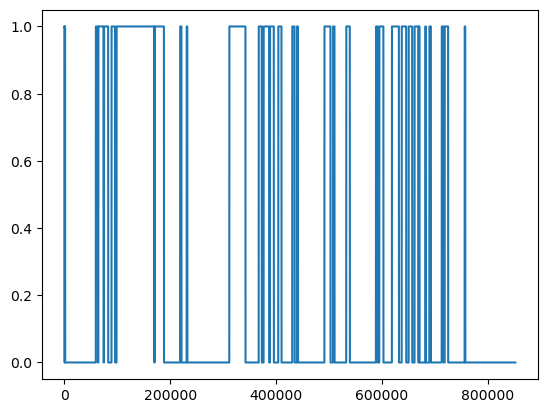

In [12]:
plt.plot(train_states)